# Inspect Cluster Lifecycle Report

This notebook loads a `graphcluster` lifecycle report artifact written during a streaming run and gives a quick way to inspect the most useful data without rerunning the trajectory pipeline.

The current report artifact contains:
- trajectory-level summary counts
- per-frame cluster counts and changed-atom counts
- birth, death, split, and merge events
- per-atom switch counts
- simple cluster lifetime records


In [4]:
import sys
print(sys.executable)

/n/holylabs/kozinsky_lab/Users/lsteinberger/conda/envs/nequip311/bin/python


In [5]:
from pathlib import Path
from pprint import pprint

from graphcluster.analysis.lifecycle_report import ClusterLifecycleReport

# Change this path if you want to inspect a different run.
REPORT_PATH = Path("/n/home12/lsteinberger/systems/hpt/analysis/cluster/outputs/hpt_600k_geometry/cluster_lifecycle_report.json")

if not REPORT_PATH.exists():
    raise FileNotFoundError(f"Could not find report artifact: {REPORT_PATH}")

report = ClusterLifecycleReport.from_path(REPORT_PATH)
REPORT_PATH


PosixPath('/n/home12/lsteinberger/systems/hpt/analysis/cluster/outputs/hpt_600k_geometry/cluster_lifecycle_report.json')

In [6]:
print("Source:", report.source_path)
print("Summary:")
pprint(report.get_summary_table())

print("\nEvent counts:")
pprint(report.get_event_counts())


Source: /n/home12/lsteinberger/systems/hpt/analysis/cluster/outputs/hpt_600k_geometry/cluster_lifecycle_report.json
Summary:
{'num_atoms': 1312,
 'num_frames': 20,
 'num_tracked_clusters': 495,
 'total_births': 495,
 'total_deaths': 457,
 'total_merges': 308,
 'total_splits': 309}

Event counts:
{'total_births': 495,
 'total_deaths': 457,
 'total_merges': 308,
 'total_splits': 309}


In [7]:
births = report.get_births()
deaths = report.get_deaths()
splits = report.get_splits()
merges = report.get_merges()

print("Birth frames:", len(births))
print("Death frames:", len(deaths))
print("Split frames:", len(splits))
print("Merge frames:", len(merges))

print("\nFirst few birth events:")
pprint(births[:3])

print("\nFirst few death events:")
pprint(deaths[:3])

print("\nFirst split frame:")
pprint(splits[:1])

print("\nFirst merge frame:")
pprint(merges[:1])


Birth frames: 20
Death frames: 19
Split frames: 19
Merge frames: 19

First few birth events:
[{'cluster_ids': [0,
                  1,
                  2,
                  3,
                  4,
                  5,
                  6,
                  7,
                  8,
                  9,
                  10,
                  11,
                  12,
                  13,
                  14,
                  15,
                  16,
                  17,
                  18,
                  19,
                  20,
                  21,
                  22,
                  23,
                  24,
                  25,
                  26,
                  27,
                  28,
                  29,
                  30,
                  31,
                  32,
                  33,
                  34,
                  35,
                  36],
  'frame_index': 0},
 {'cluster_ids': [37,
                  38,
                  39,
               

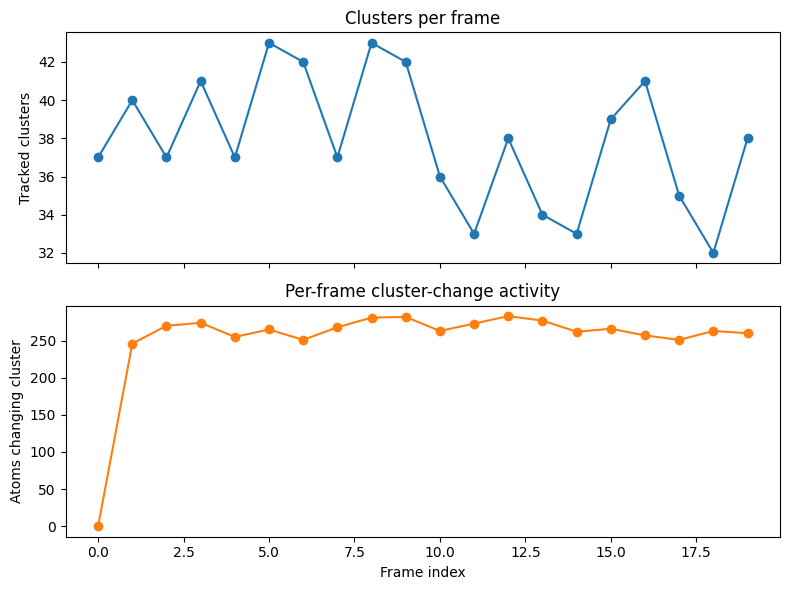

In [8]:
fig, axes = report.plot_cluster_count_timeseries()


Number of atoms: 1312
Max switch count: 19
Atoms with at least one switch: 602

Top active atoms:
[{'atom_index': 1152, 'switch_count': 19},
 {'atom_index': 1153, 'switch_count': 19},
 {'atom_index': 1156, 'switch_count': 19},
 {'atom_index': 1157, 'switch_count': 19},
 {'atom_index': 1160, 'switch_count': 19},
 {'atom_index': 1161, 'switch_count': 19},
 {'atom_index': 1162, 'switch_count': 19},
 {'atom_index': 1163, 'switch_count': 19},
 {'atom_index': 1168, 'switch_count': 19},
 {'atom_index': 1169, 'switch_count': 19}]


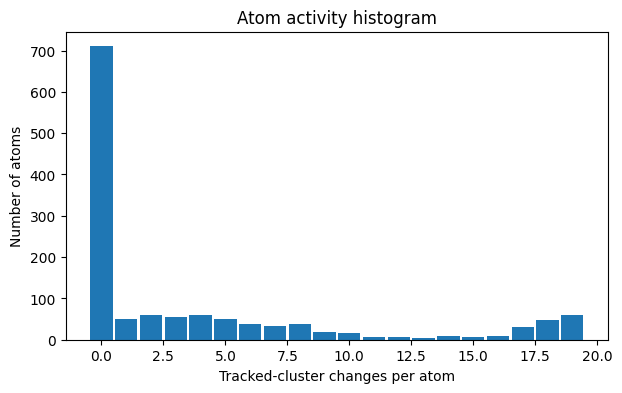

In [9]:
atom_switch_counts = report.get_atom_switch_counts()

print("Number of atoms:", len(atom_switch_counts))
print("Max switch count:", max(atom_switch_counts) if atom_switch_counts else 0)
print("Atoms with at least one switch:", report.get_num_active_atoms(min_switches=1))

print("\nTop active atoms:")
pprint(report.get_top_atoms_by_switches(10))

fig, ax = report.plot_atom_switch_histogram()


Top cluster lifetimes:
[{'cluster_id': 0,
  'first_seen_frame': 0,
  'frames_observed': 20,
  'last_seen_frame': 19},
 {'cluster_id': 1,
  'first_seen_frame': 0,
  'frames_observed': 20,
  'last_seen_frame': 19},
 {'cluster_id': 2,
  'first_seen_frame': 0,
  'frames_observed': 20,
  'last_seen_frame': 19},
 {'cluster_id': 3,
  'first_seen_frame': 0,
  'frames_observed': 20,
  'last_seen_frame': 19},
 {'cluster_id': 4,
  'first_seen_frame': 0,
  'frames_observed': 20,
  'last_seen_frame': 19},
 {'cluster_id': 5,
  'first_seen_frame': 0,
  'frames_observed': 20,
  'last_seen_frame': 19},
 {'cluster_id': 6,
  'first_seen_frame': 0,
  'frames_observed': 20,
  'last_seen_frame': 19},
 {'cluster_id': 7,
  'first_seen_frame': 0,
  'frames_observed': 20,
  'last_seen_frame': 19},
 {'cluster_id': 8,
  'first_seen_frame': 0,
  'frames_observed': 20,
  'last_seen_frame': 19},
 {'cluster_id': 90,
  'first_seen_frame': 2,
  'frames_observed': 5,
  'last_seen_frame': 6}]


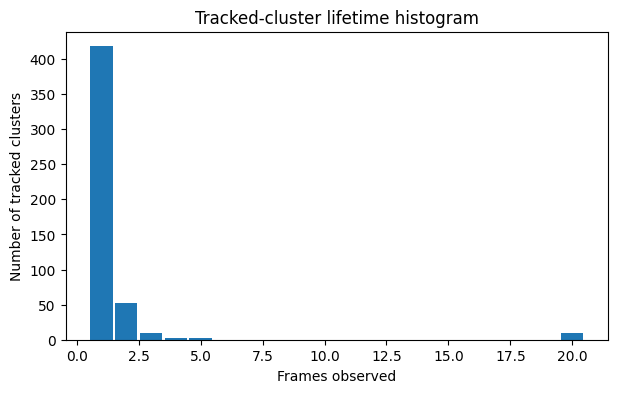

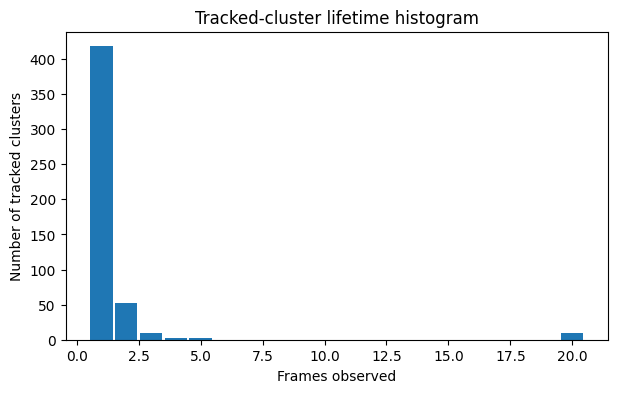

In [ ]:
print("Top cluster lifetimes:")
pprint(report.get_longest_lived_clusters(10))

fig, ax = report.plot_cluster_lifetime_histogram()
fig


## Next ideas

Natural extensions for this notebook later:
- filter events for a specific frame or tracked cluster
- compare report events against the visualization artifact for the same frame
- plot match-confidence distributions once those are exposed on the report facade
- export selected tables to CSV for external analysis
